In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [2]:
df = pd.read_csv('calibration_aggregate.csv')

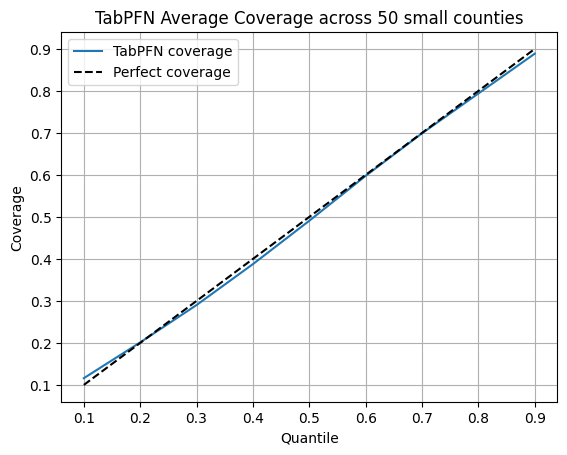

In [3]:
plt.plot(df['quantile'], df['observed_coverage'], label='TabPFN coverage')

# plto y=x line
plt.plot(df['quantile'], df['quantile'], 'k--', label='Perfect coverage')

plt.grid()
plt.legend()
plt.xlabel('Quantile')
plt.ylabel('Coverage')
plt.title('TabPFN Average Coverage across 50 small counties')
plt.show()


In [4]:
df2 = pd.read_csv('calibration_per_county.csv')

In [8]:
# compute average error per fips
# also show the n_observations per fips
df_errors = df2.groupby('fips').agg({'error': 'mean', 'n_predictions': 'mean'}).sort_values(by='error', ascending=False)
df_errors.head(15).index.values

array([28021, 30069, 28163,  2275, 28139, 16033, 28037, 28005, 29149,
        1041,  2185, 28009, 28053,  1075, 30051])

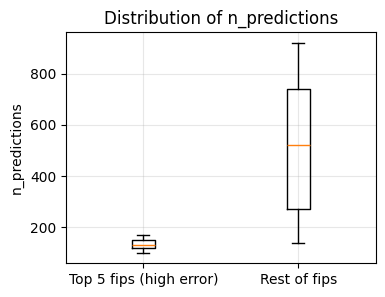

In [47]:
plt.figure(figsize=(4, 3))
plt.boxplot([df_errors.iloc[:5]['n_predictions'], df_errors.iloc[5:]['n_predictions']], 
            tick_labels=['Top 5 fips (high error)', 'Rest of fips'])
plt.ylabel('n_predictions')
plt.title('Distribution of n_predictions')
plt.grid(True, alpha=0.3)
plt.show();

In [34]:
df2['n_predictions'].describe()

count    450.000000
mean     481.200000
std      269.859949
min      100.000000
25%      210.000000
50%      455.000000
75%      730.000000
max      920.000000
Name: n_predictions, dtype: float64

In [30]:
bad_fips = 30069
df3 = df2[df2['fips'] == bad_fips]
df3

,fips,quantile,coverage,error,n_predictions
279,30069,0.1,0.038462,0.061538,130
280,30069,0.2,0.138462,0.061538,130
281,30069,0.3,0.153846,0.146154,130
282,30069,0.4,0.246154,0.153846,130
283,30069,0.5,0.392308,0.107692,130
284,30069,0.6,0.630769,0.030769,130
285,30069,0.7,0.738462,0.038462,130
286,30069,0.8,0.776923,0.023077,130
287,30069,0.9,0.830769,0.069231,130


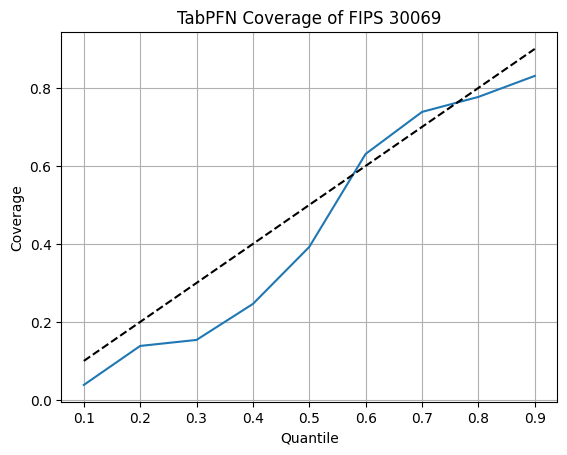

In [31]:
plt.plot(df3['quantile'], df3['coverage'])
plt.plot(df3['quantile'], df3['quantile'], 'k--')
plt.grid()
plt.xlabel('Quantile')
plt.ylabel('Coverage')
plt.title(f'TabPFN Coverage of FIPS {bad_fips}')
plt.show()
